# Dimensionality Reduction

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain the goals and trade-offs of dimensionality reduction and select an appropriate assessment metric
- Derive and apply Principal Component Analysis (PCA) from the covariance matrix eigendecomposition
- Use the scree plot and stress curve to choose the number of components
- Reconstruct and generate data points from a PCA low-dimensional representation
- Apply Kernel PCA to nonlinear datasets and explain the role of the kernel hyperparameter
- Apply Linear Discriminant Analysis (LDA) as a supervised alternative to PCA and use it as a feature extractor for classification
- Describe the principles of manifold learning (MDS, t-SNE, UMAP, PHATE) and compare them to PCA
- Apply UMAP for fast, projectable nonlinear dimensionality reduction
- Apply Incremental PCA for memory-efficient processing of large datasets
- Recognize when PHATE is preferred for trajectory-structured data
- Recognize the autoencoder as a neural-network approach to dimensionality reduction
:::

Working with high-dimensional data is challenging, and one common strategy is to reduce the number of dimensions while retaining as much useful structure as possible. This is called **dimensionality reduction**.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

plt.style.use('../settings/plot_style.mplstyle')
clrs = np.array([p['color'] for p in plt.rcParams['axes.prop_cycle']])

digits = load_digits()
X_mnist = np.array(digits.data)
y_mnist = np.array(digits.target)

def show_image(digit_data, n, ax=None, title=None, vmin=0, vmax=16, cmap='binary'):
    """Display the n-th row of data as an 8×8 grayscale image.

    For eigenvectors or other data not in [0, 16], pass vmin=None, vmax=None
    and a diverging cmap such as 'RdBu_r'.
    """
    if ax is None:
        fig, ax = plt.subplots()
    img = digit_data[n].reshape(8, 8)
    cm = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.get_figure().colorbar(cm, ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)

## Overview of Dimensionality Reduction

### Practical Uses

Dimensionality reduction algorithms serve several practical purposes:

- **Compression** — storing fewer numbers to represent each observation
- **Denoising** — reconstructing a cleaner signal from a noisy input
- **Interpretation** — projecting to 2D or 3D for visualization
- **Model efficiency** — training faster and more robust models on fewer features

We focus primarily on interpretation and model efficiency, but the algorithms are the same regardless of the downstream use.

### Considerations

When choosing a dimensionality reduction method, the following properties matter:

- **Matrix rank** — how many truly independent dimensions does the data occupy?
- **Linearity** — are the relevant patterns linear or nonlinear in the original feature space?
- **Projectability** — can a new high-dimensional point be mapped into the low-dimensional space?
- **Invertibility** — can a low-dimensional point be mapped back into the original space?
- **Supervision** — are training labels used when learning the reduced representation?

No single method satisfies all of these simultaneously; the choice depends on the problem.

### Assessing Performance

#### Retained Variance

One natural metric is the fraction of the original variance that is preserved in the low-dimensional representation. This is most natural for PCA, where the variance along each principal component direction is explicitly computed.

#### Stress

The **stress** function compares pairwise distances in the low-dimensional space to pairwise distances in the full-dimensional space:

$$S = \left(\frac{\sum_{i}\sum_{j > i}(d_{ij} - \|\mathbf{x}_i - \mathbf{x}_j\|)^2}{\sum_{i}\sum_{j > i} d_{ij}^2}\right)^{1/2}$$

where $d_{ij}$ is the distance between points $i$ and $j$ in the high-dimensional space and $\mathbf{x}_i$ is the corresponding low-dimensional vector. A stress of 0 means distances are perfectly preserved; larger values indicate more distortion.

In [2]:
from scipy.spatial.distance import pdist

def stress(X_reduced, X):
    D_red = pdist(X_reduced)
    D_tot = pdist(X)
    numerator = np.sum((D_tot - D_red)**2)
    denom = np.sum(D_tot**2)
    return np.sqrt(numerator / denom)

#### Visualization and Model Performance

Where possible, plotting the low-dimensional representation and visually inspecting cluster structure is a powerful qualitative check. When labeled data are available, a complementary approach is to train a supervised model in both the original and reduced spaces: if model accuracy does not drop substantially, the key structure has been preserved.

:::{exercise}
:label: ex-eda-stress-variance

Retained variance and stress do not always agree. Consider the three vertices of an equilateral triangle centered at the origin:

```python
tri = np.array([[0, 1],
                [-np.sqrt(3)/2, -0.5],
                [ np.sqrt(3)/2, -0.5]])
```

(a) Project these points onto the $x$-axis and onto the $y$-axis (a 1D projection in each case), and verify that the **projected variance is identical** for the two directions. (In fact, this configuration has the same variance along *every* direction — try a few others to convince yourself.)

(b) Using the `stress` function defined above, compute the stress of each projection. (Hint: `pdist` expects a 2D array, so reshape each projection with `.reshape(-1, 1)`.) Which direction preserves the triangle's geometry better?

(c) Retained variance cannot distinguish these two projections, but stress can. Explain in one or two sentences what stress "sees" that variance does not.
:::

## Principal Component Analysis (PCA)

PCA may already be familiar from the regression module, where we used it to build principal component regression models. Here we slow down and take a closer look at how it actually works, because the ideas behind it — variance, covariance, and eigendecomposition — are the foundation for almost every other method in this chapter.

The central idea is simple to state: PCA finds an orthonormal set of directions — the **principal components** — along which the variance of the data is maximized. The first component points in the direction of greatest spread, the second in the direction of greatest remaining spread perpendicular to the first, and so on. These directions turn out to be the eigenvectors of the sample covariance matrix, sorted by decreasing eigenvalue, so we can compute them with the linear algebra tools from Module 1.

### The Covariance Matrix

Text(0.5, 1.0, 'MNIST covariance matrix')

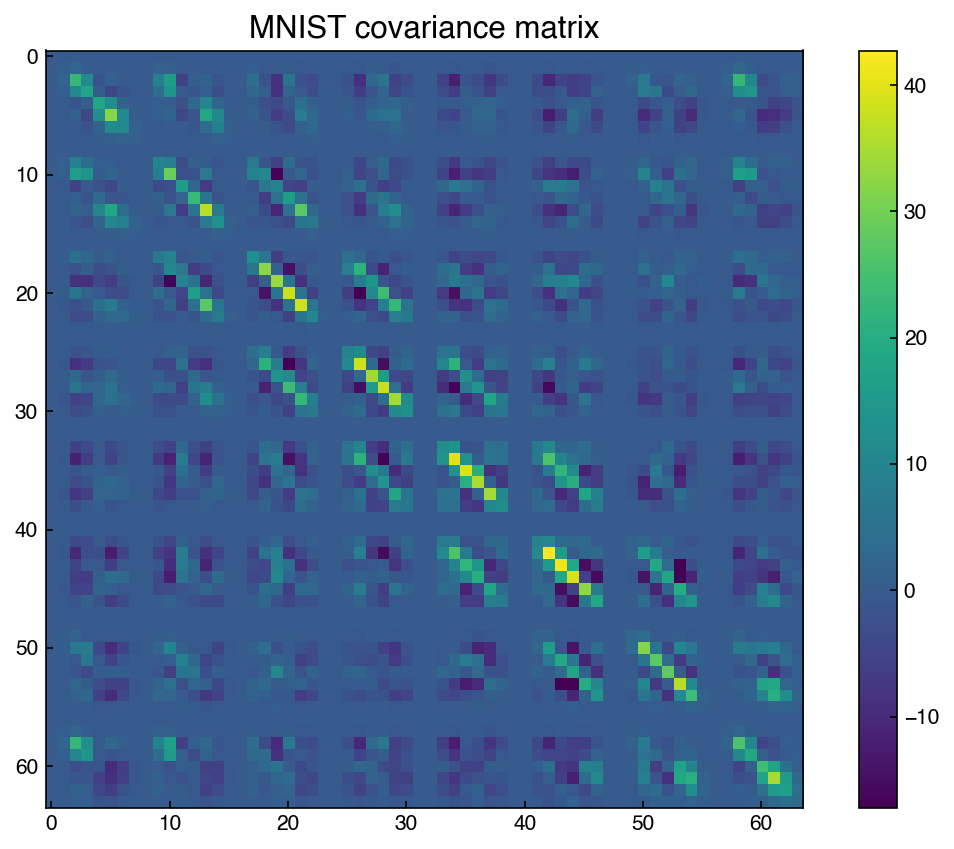

In [3]:
C = np.cov(X_mnist.T)

fig, ax = plt.subplots()
c = ax.imshow(C)
fig.colorbar(c, ax=ax)
ax.set_title('MNIST covariance matrix')

:::{note}
**Covariance matrix vs. correlation matrix:** The correlation matrix (from Topic 5.1) normalizes each entry by the standard deviations of the two features so that all values fall in $[-1, 1]$. The covariance matrix does not normalize, so its entries reflect both the correlation strength and the magnitude of the feature variances. For MNIST all pixels share the same unit (intensity 0–16), so the covariance is directly comparable across features. The visible 8×8 block structure reflects the spatial layout of the image: neighboring pixels within the same digit region tend to covary strongly, producing blocks of size 8 along both axes of the 64×64 matrix.
:::

### Eigendecomposition

The principal components are the eigenvectors of $C$, sorted by decreasing eigenvalue. Each eigenvalue equals the variance of the data projected onto the corresponding eigenvector. To see why, project the (centered) data onto a unit eigenvector $\mathbf{v}$: the projected values are $X\mathbf{v}$, and their variance is $\mathbf{v}^T C \mathbf{v} = \lambda \mathbf{v}^T \mathbf{v} = \lambda$. Conceptually, the covariance matrix stretches any direction by an amount that reflects the spread of the data along it; an eigenvector is a direction that gets stretched without being rotated, so its stretch factor $\lambda$ *is* the variance in that direction.

In [4]:
eig_vals, eig_vecs = np.linalg.eig(C)
eig_vecs = eig_vecs.T   # eigenvectors are columns by default; transpose for row indexing

# Sort from largest to smallest eigenvalue
sorted_idxs = list(np.argsort(eig_vals))
sorted_idxs.reverse()
eig_vals = eig_vals[sorted_idxs]
eig_vecs = eig_vecs[sorted_idxs, :]

The eigenvectors can be visualized as 8×8 images. The first principal component is the direction of maximum variance in the 64-dimensional pixel space:

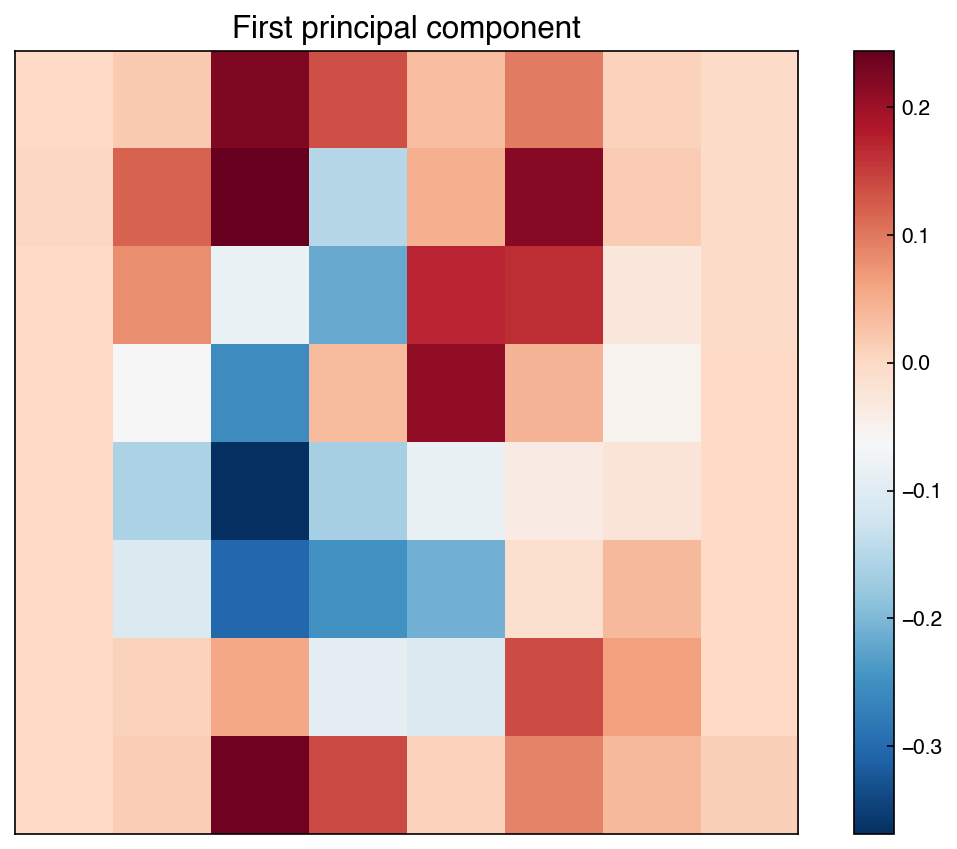

In [5]:
show_image(eig_vecs, 0, title='First principal component',
           vmin=None, vmax=None, cmap='RdBu_r')

The pattern is clearly not random — it reflects the global structure shared across digit images.

**Demonstration: Rank of the covariance matrix**

The rank of a matrix equals the number of non-zero eigenvalues. For MNIST, the data has 1,797 samples and 64 features, so the covariance matrix can have rank at most $\min(1797-1, 64) = 64$. (The $-1$ arises because subtracting the mean removes one independent direction — a covariance matrix built from $n$ samples has rank at most $n-1$. With far more samples than features here, the binding limit is the 64 features.)

In [6]:
print(f'Rank of covariance matrix: {np.linalg.matrix_rank(C)}')
non_zero = np.sum(np.abs(eig_vals) > 1e-10)
print(f'Eigenvalues above 1e-10:   {non_zero}')
print(f'Smallest eigenvalue:       {eig_vals[-1]:.4f}')

Rank of covariance matrix: 61
Eigenvalues above 1e-10:   61
Smallest eigenvalue:       0.0000


A rank less than 64 confirms that the 64 pixel features do not span a fully independent 64-dimensional space — the data lives on a lower-dimensional subspace.

### Dimensionality Reduction as Low-Rank Approximation

It is worth pausing to notice that so far we have not reduced the dimensionality at all. We have only found a new orthonormal set of axes aligned with the data and rotated the data onto them — all 64 dimensions are still there. The reduction happens when we *keep only the first $k$ of these new axes* and discard the rest. Because the axes are sorted by variance, dropping the trailing ones throws away as little structure as possible.

This intuition can be made precise: PCA finds the best rank-$k$ approximation of the data matrix $\mathbf{X}$ in the Frobenius norm sense:

$$\min_{\mathbf{A}}\; \|\mathbf{X} - \mathbf{A}\|_F \quad \text{subject to } \operatorname{rank}(\mathbf{A}) \leq k$$

where $\|\mathbf{M}\|_F = \sqrt{\sum_{i,j} M_{ij}^2}$. The solution is to project $\mathbf{X}$ onto the top $k$ eigenvectors of the covariance matrix. Reducing $k$ compresses the data; the fraction of variance retained is $\sum_{i=1}^k \lambda_i / \sum_{i=1}^n \lambda_i$.

In [7]:
k = 20
projector = eig_vecs[:k, :].T   # shape (64, k)
X_k = np.dot(X_mnist, projector)   # shape (n_samples, k)

retained = sum(eig_vals[:k]) / sum(eig_vals)
print(f'Retained variance with k={k}: {retained:.3f}')

Retained variance with k=20: 0.894


### Scree Plot

A **scree plot** shows cumulative retained variance as a function of the number of components. It is the standard tool for choosing $k$.

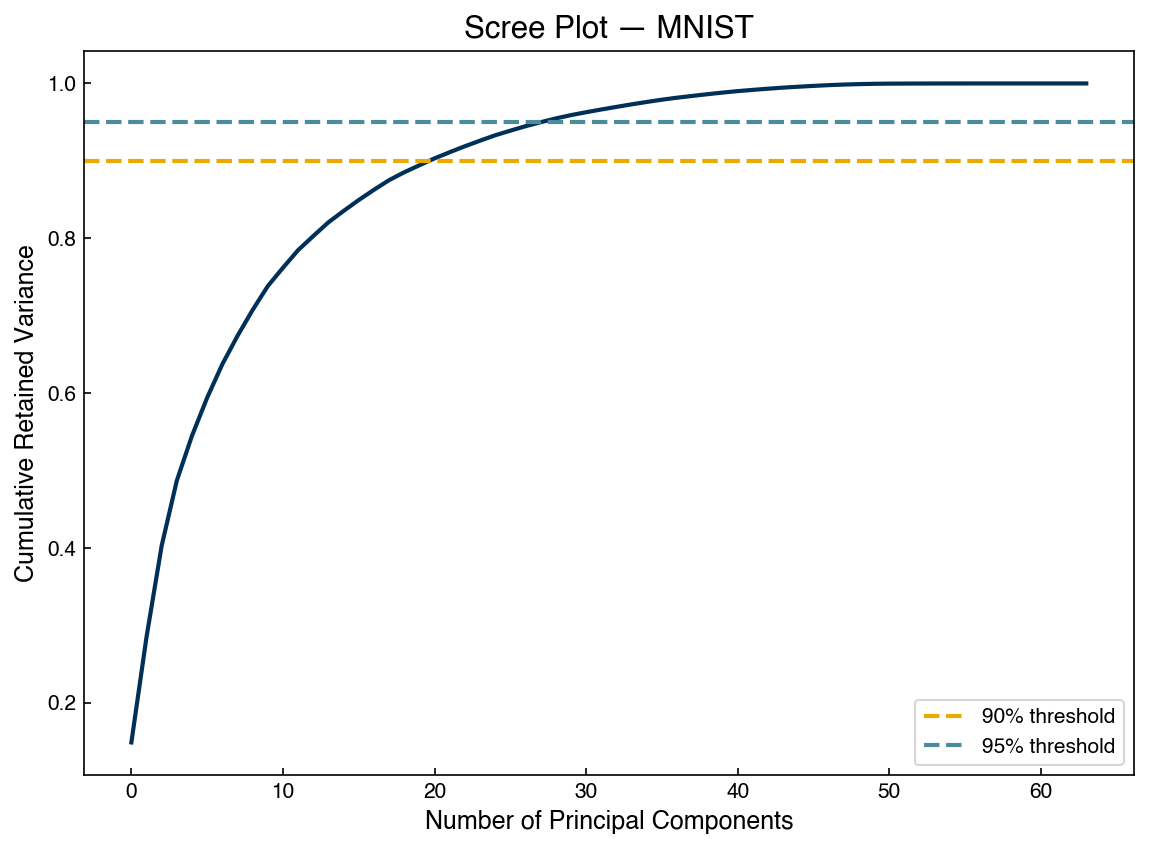

In [8]:
fig, ax = plt.subplots()
N = len(eig_vals)
ax.plot(range(N), np.cumsum(eig_vals) / sum(eig_vals), color=clrs[0])
ax.axhline(0.90, color=clrs[1], linestyle='--', label='90% threshold')
ax.axhline(0.95, color=clrs[2], linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Retained Variance')
ax.set_title('Scree Plot — MNIST')
ax.legend()

:::{exercise}
:label: ex-eda-pca-scree

Using the scree plot data above, determine the minimum number of principal components needed to retain at least **90%** of the total variance in the MNIST dataset. Then load the Dow dataset (`data/impurity_dataset-training.xlsx`) and apply PCA to report the number of components required for 90% retained variance. Which dataset is more compressible, and why?
:::

### Stress vs. Number of Components

Retained variance measures global compression quality. The stress metric measures how well pairwise distances are preserved — a complementary view:

Text(0.5, 1.0, 'PCA Stress vs. Components — MNIST')

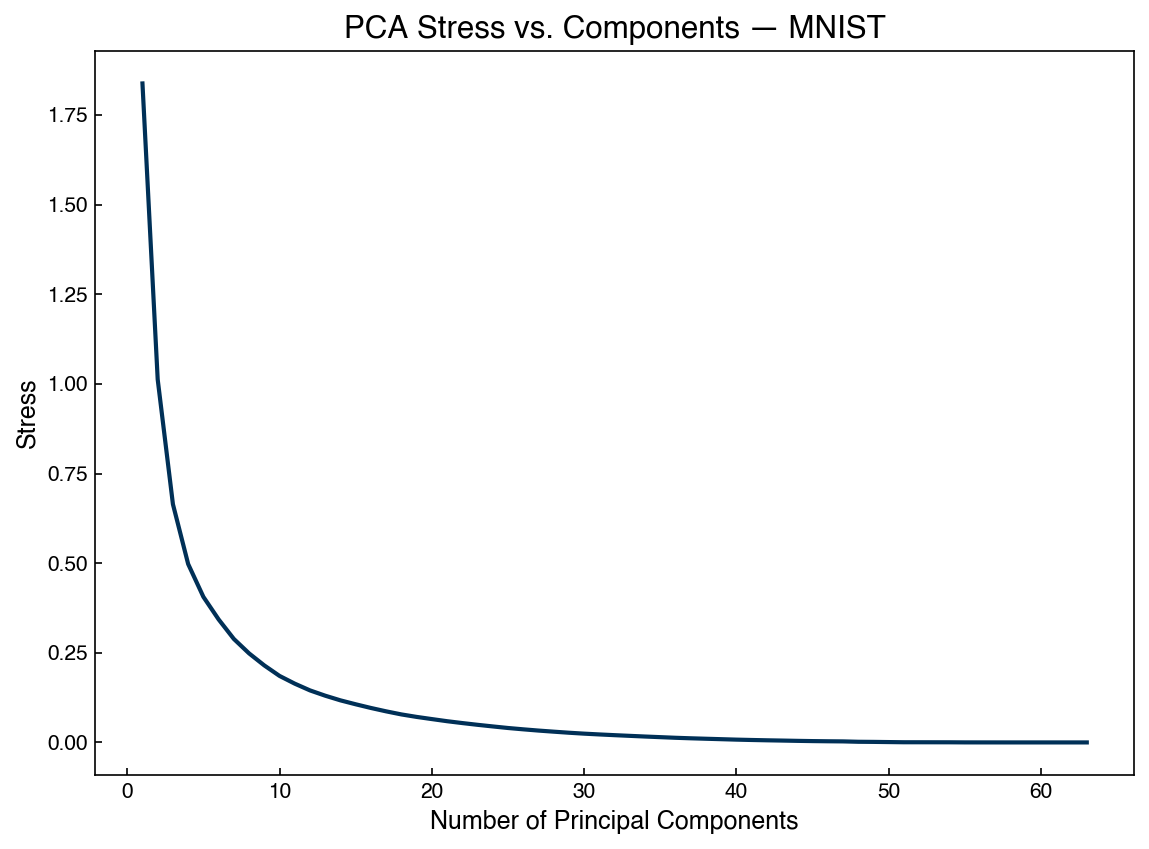

In [9]:
stresses = []
for k in range(1, N):
    proj = eig_vecs[:k, :].T
    X_k_tmp = np.dot(X_mnist, proj)
    stresses.append(stress(X_mnist, X_k_tmp))

fig, ax = plt.subplots()
ax.plot(range(1, N), stresses, color=clrs[0])
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Stress')
ax.set_title('PCA Stress vs. Components — MNIST')

Stress decreases monotonically as more components are included. It drops quickly at first and then levels off — the same "elbow" pattern as the scree plot, suggesting that roughly 20–30 components capture most of the geometric structure.

### 2D Projection and Visualization

One of the most common uses of PCA is to project all the way down to two dimensions so the data can be plotted. Each 64-pixel image becomes a single point whose coordinates are its scores along the two highest-variance directions — in effect, the two-number summary of each image that loses the least information. Plotting these points reveals structure that is impossible to see in the raw 64-dimensional data:

Text(0.5, 1.0, 'MNIST projected onto first two PCs')

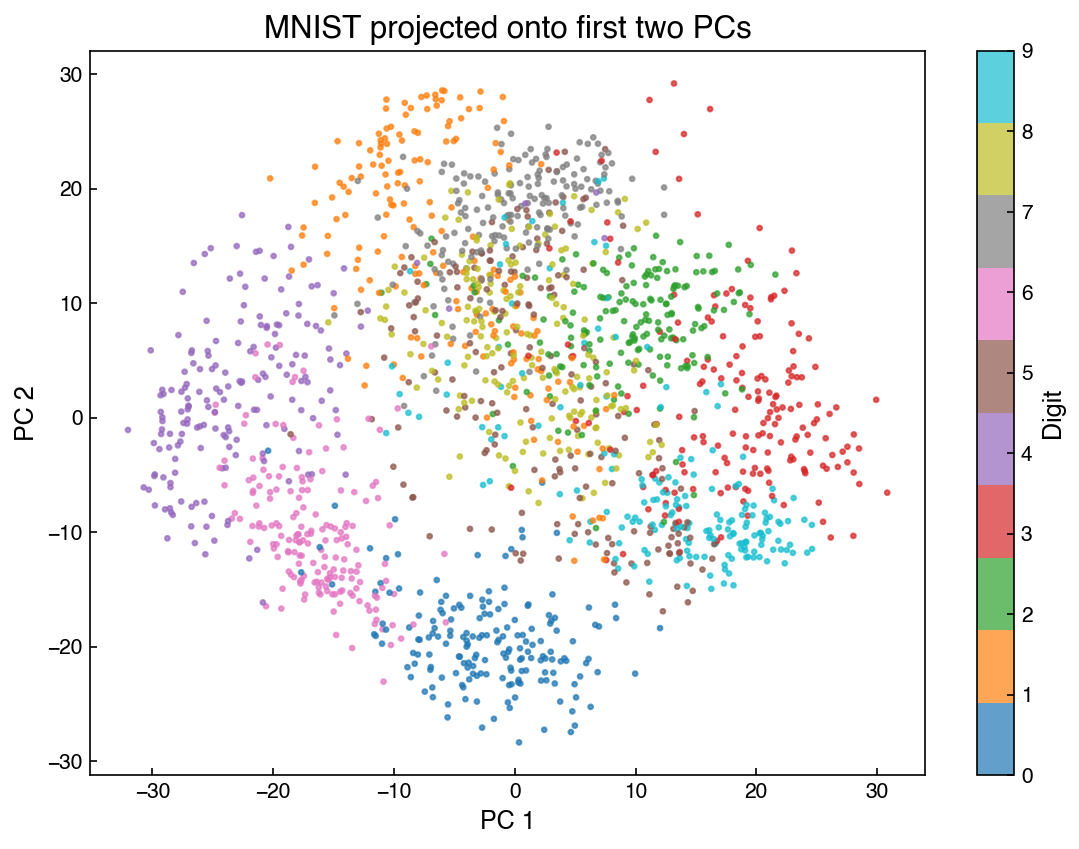

In [10]:
k = 2
projector = eig_vecs[:k, :].T
X_k = np.dot(X_mnist, projector)

fig, ax = plt.subplots()
sc = ax.scatter(X_k[:, 0], X_k[:, 1], c=y_mnist, cmap='tab10', s=5, alpha=0.7)
fig.colorbar(sc, ax=ax, label='Digit')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('MNIST projected onto first two PCs')

Each color represents a different digit. PCA is *unsupervised* — the labels were not used to find these directions — yet many digits already form visible clusters. The overlap between certain digits (3, 5, 8) reflects their visual similarity in two dimensions.

### Reconstruction

Because PCA is **invertible**, we can project a low-dimensional point back to pixel space. This is useful for compression, denoising, and generating new examples.

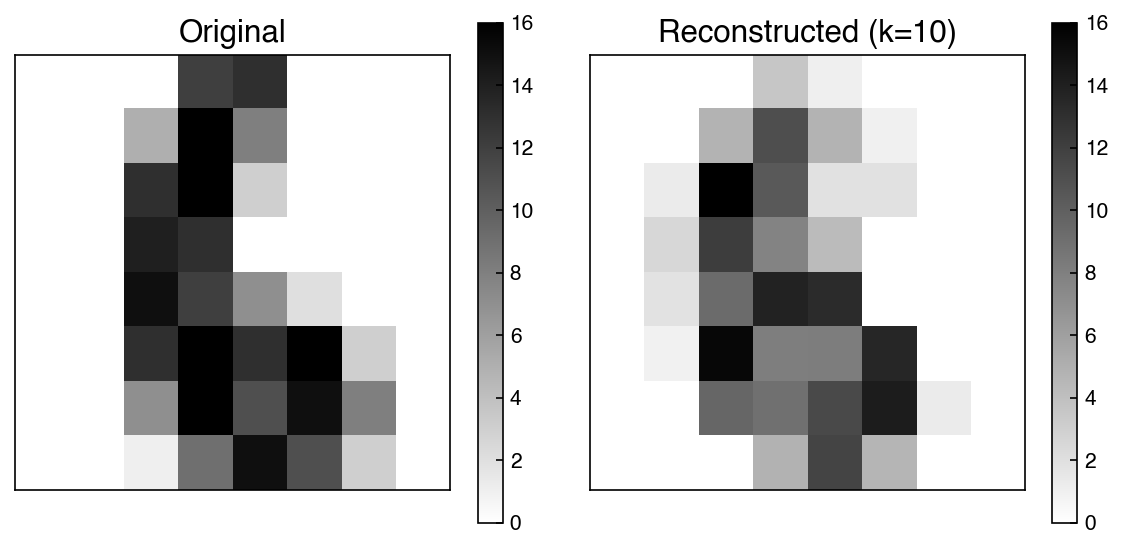

In [11]:
k = 10
projector = eig_vecs[:k, :].T
X_k = np.dot(X_mnist, projector)
X_reconstructed = np.dot(projector, X_k.T).T

index = 6
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show_image(X_mnist, index, ax=axes[0], title='Original')
show_image(X_reconstructed, index, ax=axes[1], title=f'Reconstructed (k={k})')
plt.tight_layout()

The reconstruction captures the essential shape of the digit while discarding fine detail — analogous to image compression. Noise components, which tend to be random and spread across many principal components, are also suppressed in the reconstruction.

**Demonstration: Generating an "average" digit**

Because PCA is invertible, **any** point in the low-dimensional space can be projected back to pixel space — not just points that came from real images. This means we can construct entirely new examples. The "average" digits below never existed in the dataset: for each class we average the low-dimensional representations of its members, producing a new point in the reduced space, and then project that point back to 64 pixels. This is a first taste of a *generative* model — an idea we will develop properly in the Generative Models chapter:

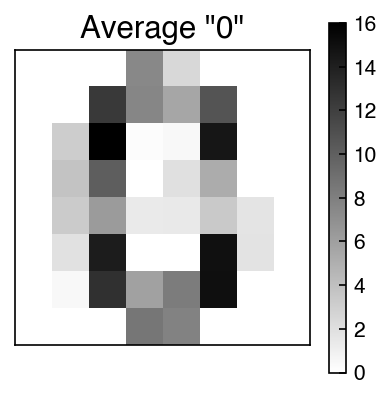

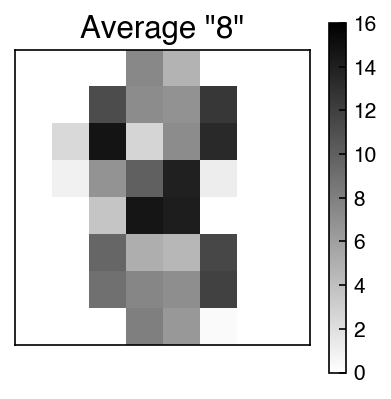

In [12]:
for target_digit in [0, 8]:
    mask = y_mnist == target_digit
    X_lowD_mean = X_k[mask].mean(axis=0)
    X_avg = np.dot(projector, X_lowD_mean).reshape(1, -1)
    fig, ax = plt.subplots(figsize=(3, 3))
    show_image(X_avg, 0, ax=ax, title=f'Average "{target_digit}"')

The average digit is a smooth template that captures the typical stroke pattern for that class, stripped of the idiosyncratic variation present in any individual example.

### scikit-learn PCA

In practice, use `sklearn.decomposition.PCA`, which is numerically stable (uses SVD internally rather than eigendecomposition of the covariance matrix) and provides convenient outputs:

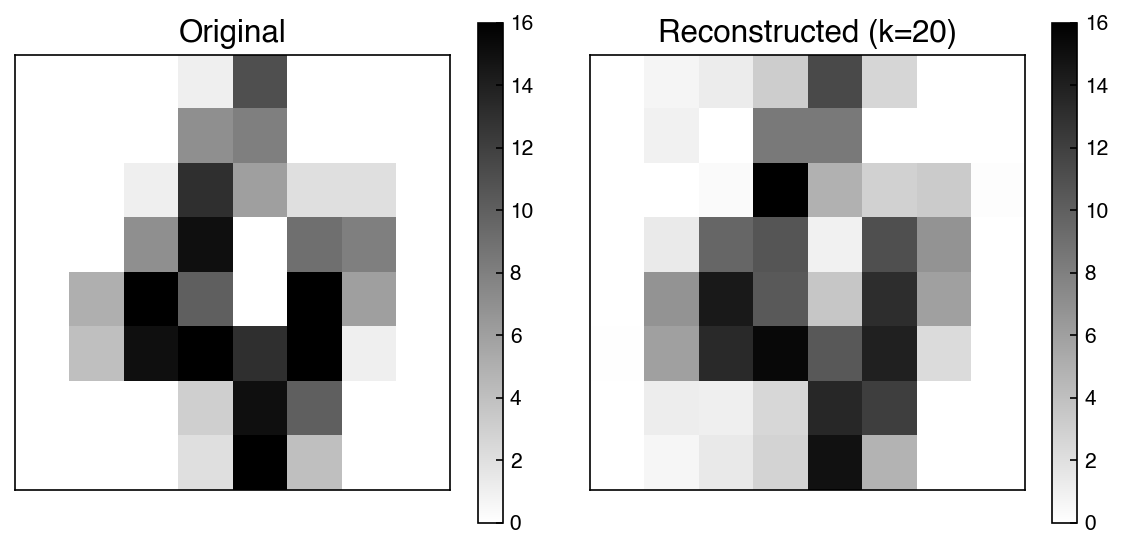

In [13]:
from sklearn.decomposition import PCA

k = 20
pca = PCA(n_components=k)
pca.fit(X_mnist)
X_k = pca.transform(X_mnist)
X_reconstructed = pca.inverse_transform(X_k)

index = 4
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show_image(X_mnist, index, ax=axes[0], title='Original')
show_image(X_reconstructed, index, ax=axes[1], title=f'Reconstructed (k={k})')
plt.tight_layout()

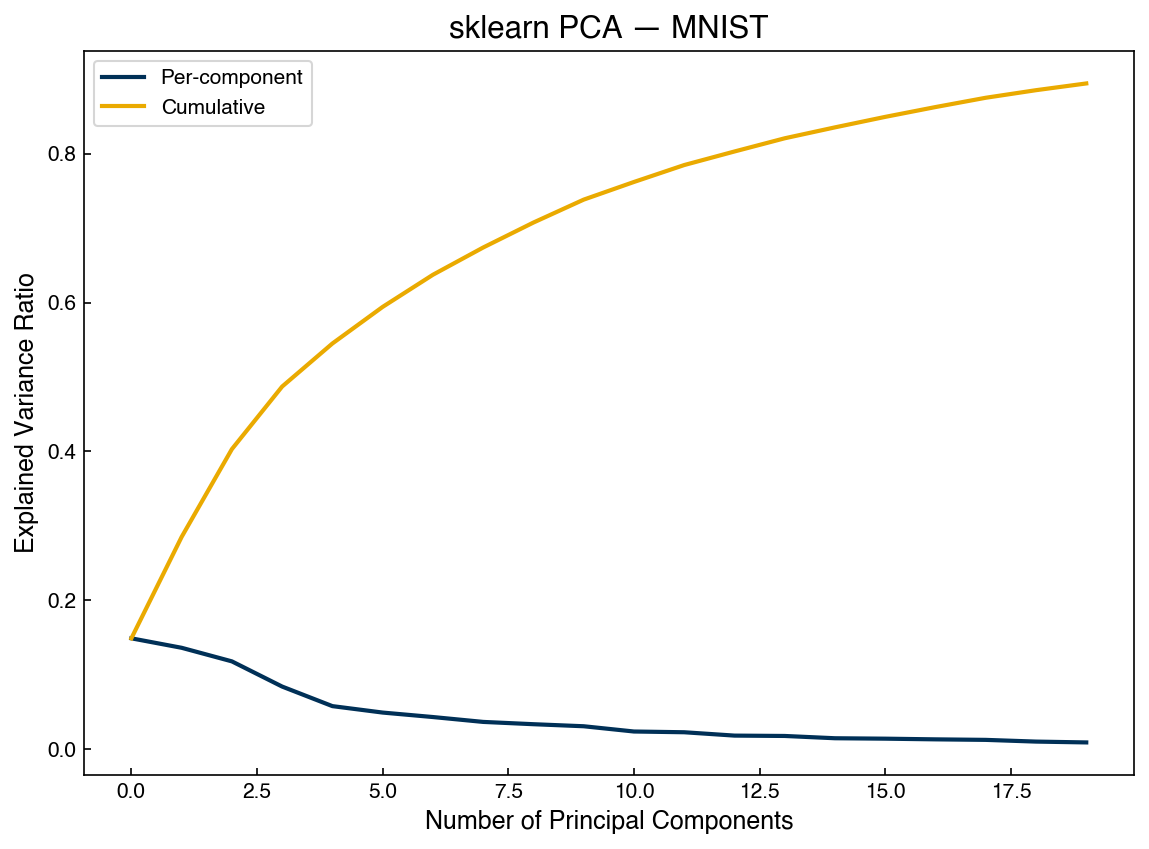

In [14]:
evr = pca.explained_variance_ratio_

fig, ax = plt.subplots()
ax.plot(range(len(evr)), evr, label='Per-component', color=clrs[0])
ax.plot(range(len(evr)), np.cumsum(evr), label='Cumulative', color=clrs[1])
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('sklearn PCA — MNIST')
ax.legend()

:::{note}
PCA is one of the most widely used dimensionality reduction techniques because it is unsupervised, projectable (new points can be mapped in), and invertible (low-dimensional points can be mapped back). Its main limitation is linearity: it cannot capture curved or otherwise nonlinear structure in the data.
:::

### Incremental PCA

Standard PCA requires the entire dataset in memory at once to compute the covariance matrix. For large industrial datasets — sensor archives with millions of time steps, high-resolution spectra, or image libraries — this can exceed available RAM. `sklearn.decomposition.IncrementalPCA` fits PCA in mini-batches using an online SVD algorithm, making it practical for out-of-core or streaming data.

In [15]:
from sklearn.decomposition import IncrementalPCA

batch_size = 200
ipca = IncrementalPCA(n_components=20, batch_size=batch_size)

# Simulate streaming: process data in chunks
for i in range(0, X_mnist.shape[0], batch_size):
    batch = X_mnist[i:i + batch_size]
    if len(batch) >= 20:   # requires n_samples >= n_components per batch
        ipca.partial_fit(batch)

X_ipca = ipca.transform(X_mnist)
print(f'Output shape: {X_ipca.shape}')
print(f'Retained variance: {ipca.explained_variance_ratio_.sum():.3f}')

Output shape: (1797, 20)
Retained variance: 0.890


The results are nearly identical to standard PCA. We can verify by comparing the explained variance ratios directly:

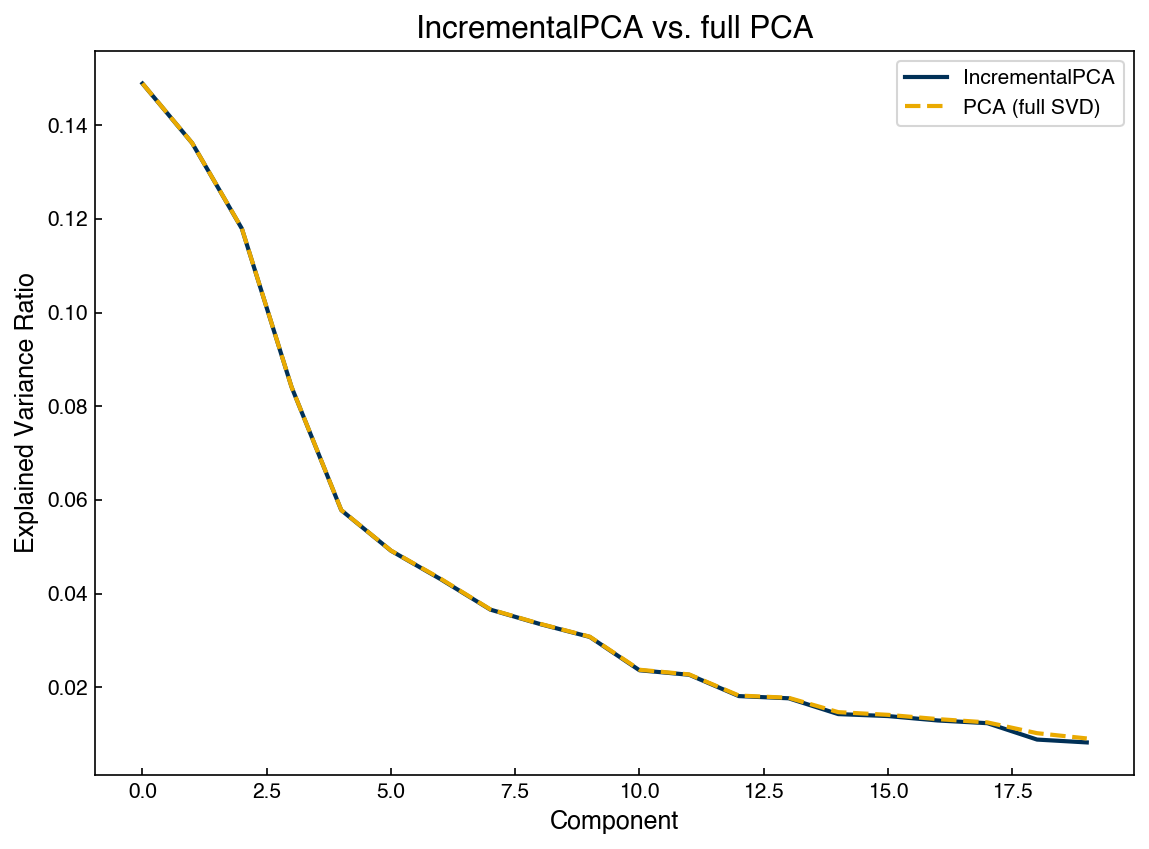

In [16]:
pca_full = PCA(n_components=20)
pca_full.fit(X_mnist)

fig, ax = plt.subplots()
ax.plot(ipca.explained_variance_ratio_, label='IncrementalPCA', color=clrs[0])
ax.plot(pca_full.explained_variance_ratio_, label='PCA (full SVD)',
        color=clrs[1], linestyle='--')
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('IncrementalPCA vs. full PCA')
ax.legend()

The two curves overlap almost exactly. The main trade-off is that `IncrementalPCA` requires specifying `n_components` in advance and is marginally less accurate than the full SVD, but for large $n$ the difference is negligible.

## Kernel PCA

The solution to PCA's linearity limitation is a familiar one: the **kernel trick**, which we met with support vector machines in [Generalized Linear Models](../3-classification/Topic3.2-Generalized_Linear_Models). The idea, briefly: instead of explicitly constructing a nonlinear feature transformation, we work with a matrix of pairwise *similarities* between points, which implicitly corresponds to operating in a much higher-dimensional feature space. Kernel PCA applies this same move to PCA — instead of the covariance matrix, it eigendecomposes a **kernel matrix**:

$$K_{ij} = \kappa(\mathbf{x}_i, \mathbf{x}_j)$$

where $\kappa$ is a kernel function. For the radial basis function (RBF) kernel:

$$\kappa_\text{rbf}(\mathbf{x}_i, \mathbf{x}_j) = \exp\!\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly similarity decays with distance: large $\gamma$ means only very close points are considered similar. Eigendecomposition of $K$ gives principal components in the (implicit) high-dimensional feature space induced by $\kappa$, capturing nonlinear structure that linear PCA misses.

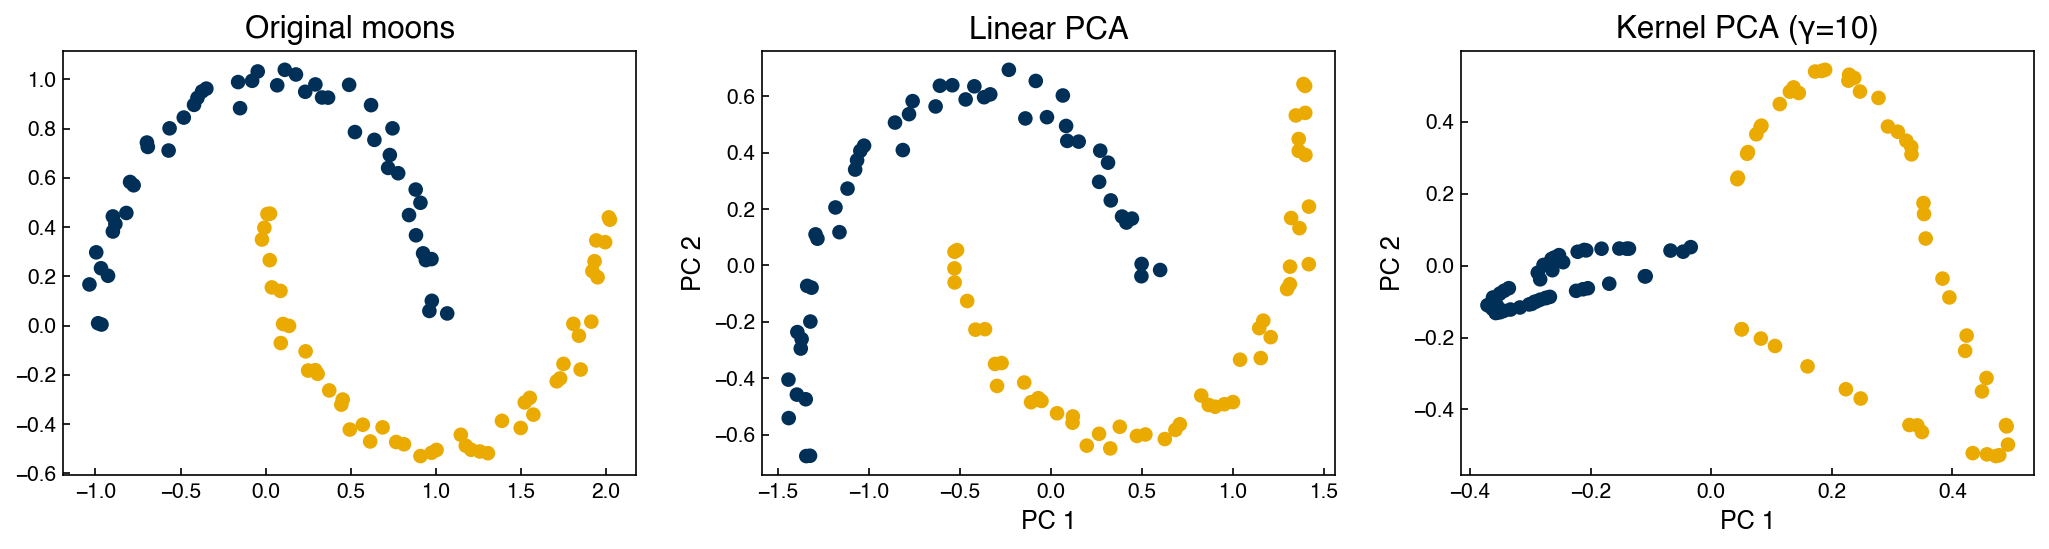

In [17]:
from sklearn.datasets import make_moons
from sklearn.decomposition import KernelPCA

X_m, y_m = make_moons(n_samples=100, random_state=0, noise=0.04)

k = 2
gamma = 10
pca_lin = PCA(n_components=k)
pca_ker = KernelPCA(n_components=k, kernel='rbf', gamma=gamma, fit_inverse_transform=True)

X_pca  = pca_lin.fit_transform(X_m)
X_kpca = pca_ker.fit_transform(X_m)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, X_plot, title in zip(axes,
                              [X_m, X_pca, X_kpca],
                              ['Original moons', 'Linear PCA', f'Kernel PCA (γ={gamma})']):
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=clrs[y_m])
    ax.set_title(title)
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[2].set_xlabel('PC 1'); axes[2].set_ylabel('PC 2')
plt.tight_layout()

Linear PCA cannot separate the two moon-shaped classes because the decision boundary is not linear. Kernel PCA with the RBF kernel maps the data to a higher-dimensional space where the classes become linearly separable, then projects back to 2D.

Kernel PCA is also invertible (when `fit_inverse_transform=True`), but with an important caveat:

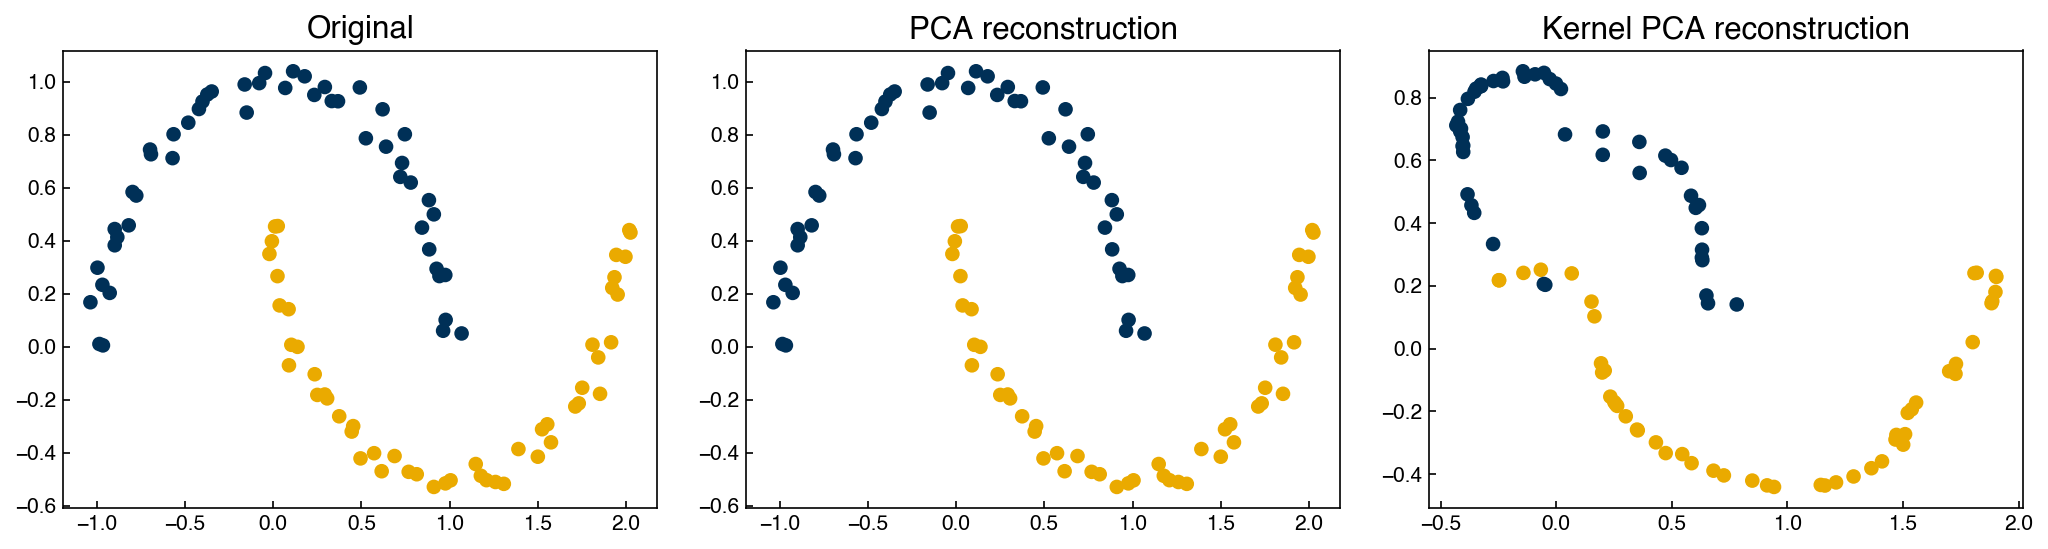

In [18]:
X_pca_recon  = pca_lin.inverse_transform(X_pca)
X_kpca_recon = pca_ker.inverse_transform(X_kpca)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, X_plot, title in zip(axes,
                              [X_m, X_pca_recon, X_kpca_recon],
                              ['Original', 'PCA reconstruction', 'Kernel PCA reconstruction']):
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=clrs[y_m])
    ax.set_title(title)
plt.tight_layout()

Compare the two reconstructions to the original. Linear PCA with both components retained reproduces the data exactly — the transform is just a rotation, so inverting it loses nothing. The kernel PCA reconstruction, in contrast, is visibly distorted: the moons are recognizable but warped. The nonlinear mapping into the implicit feature space is not exactly reversible — `inverse_transform` only *approximates* a pre-image of each point, and some information is lost in the round trip. Kernel PCA is therefore "invertible" only in this approximate sense, which is what the comparison table at the end of the chapter means by "Yes (approx.)".

:::{exercise}
:label: ex-eda-kpca-gamma

Using the moons dataset, fit `KernelPCA` with `kernel='rbf'` for five values of `gamma` spanning a wide range (e.g. 0.1, 1, 10, 100, 1000). For each, plot the 2D transformed data colored by class. Describe what happens to the separation as `gamma` increases. At what value does the transformation appear to overfit to individual points?
:::

### Other PCA Variants

PCA has many variants worth knowing:

- **Robust PCA** — handles sparse data and large outliers by decomposing the data matrix into a low-rank component plus a sparse noise component
- **Partial Least Squares (PLS)** — supervised variant that maximizes the covariance between the projected inputs and the target variable, rather than maximizing variance in the inputs alone
- **Linear Discriminant Analysis (LDA)** — supervised variant that maximizes the ratio of between-class to within-class variance, making it directly useful for classification

PLS was introduced in [High-Dimensional Regression](../2-regression/Topic2.5-High_dimensional_regression), and it is worth revisiting that section with fresh eyes now that the eigendecomposition machinery behind PCA is familiar. LDA is the subject of the next section.

## Supervised Dimensionality Reduction: LDA

Everything in this chapter so far has been *unsupervised*: PCA and its variants find directions using the feature matrix alone. But the MNIST dataset comes with labels, and ignoring them leaves information on the table. **Linear Discriminant Analysis (LDA)** uses the labels directly: instead of maximizing total variance, it finds the directions that maximize the spread *between* class centroids relative to the spread *within* each class. Mechanically it is the same eigendecomposition machinery as PCA, applied to the composite matrix $C_\text{intra}^{-1} C_\text{inter}$ instead of the covariance matrix — a step-by-step manual derivation is given in [High-Dimensional Classification](../3-classification/Topic3.4-High-dimensional_Classification).

Because the LDA directions separate class centroids, there can be at most $C - 1$ of them for $C$ classes. For the MNIST digits (10 classes, 64 pixel features), LDA therefore projects down to at most 9 components:

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_mnist, y_mnist)
X_lda = lda.transform(X_mnist)
print(f'LDA projected shape: {X_lda.shape}')

LDA projected shape: (1797, 9)


How much does supervision help? We can compare the first two LDA components against the first two components of a 9-component PCA on the same data:

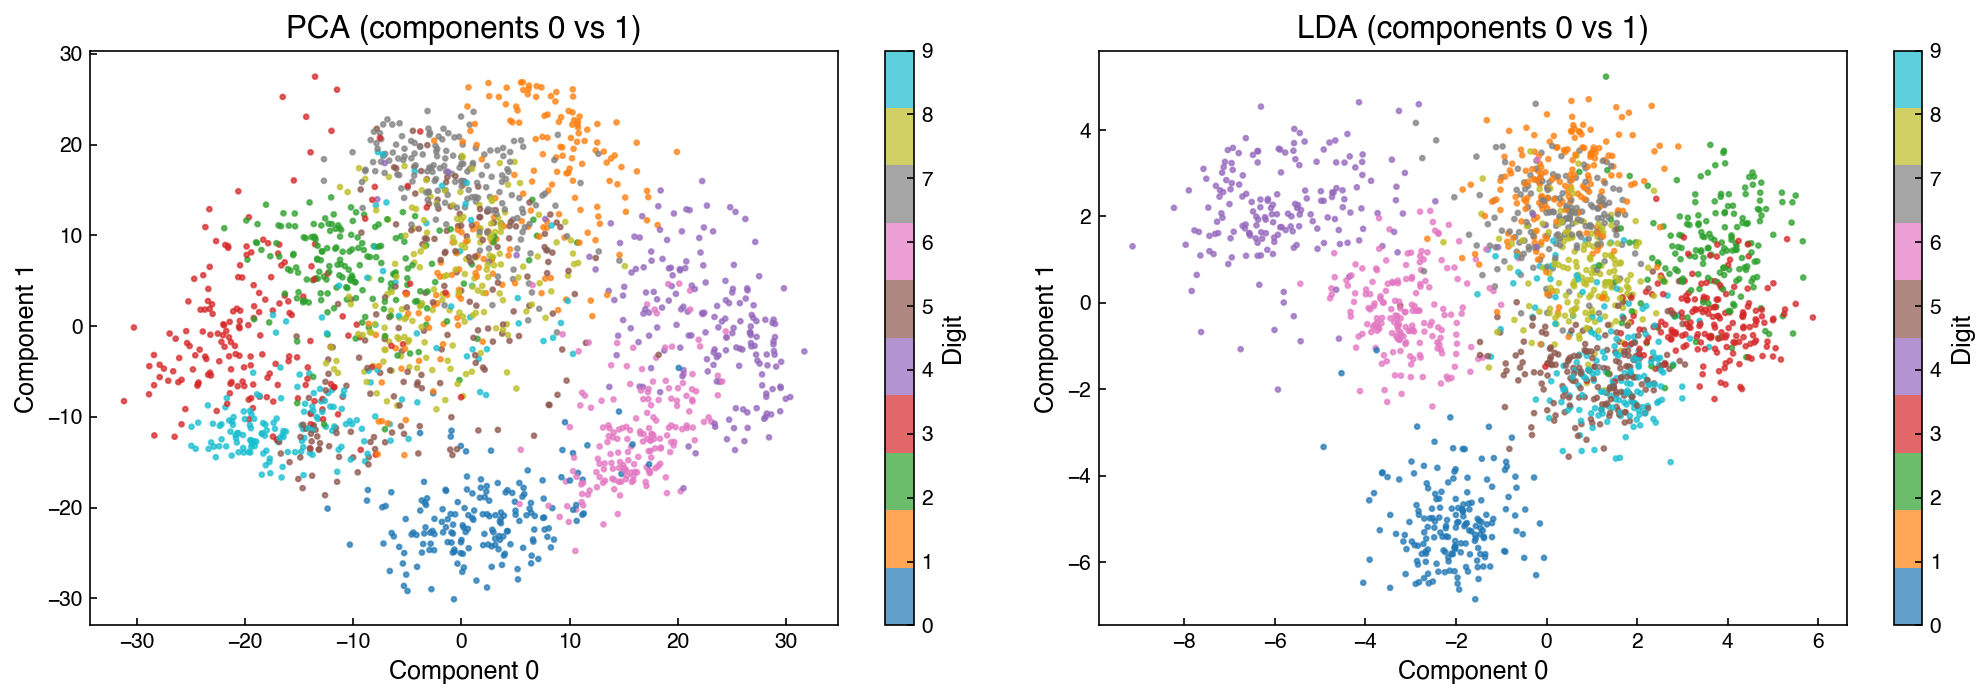

In [20]:
pca9 = PCA(n_components=9)
X_pca9 = pca9.fit_transform(X_mnist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, X_plot, title in zip(axes, [X_pca9, X_lda], ['PCA', 'LDA']):
    sc = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_mnist, cmap='tab10', s=5, alpha=0.7)
    fig.colorbar(sc, ax=ax, label='Digit')
    ax.set_xlabel('Component 0')
    ax.set_ylabel('Component 1')
    ax.set_title(f'{title} (components 0 vs 1)')
plt.tight_layout()

The LDA projection shows substantially better cluster separation than PCA because LDA explicitly maximizes the ratio of between-class to within-class variance. PCA simply captures directions of maximum total variance in the data, which may mix classes.

### LDA as a Feature Extractor

LDA is projectable — `transform` maps new points into the reduced space — so it can serve as a preprocessing step in a supervised pipeline. This is exactly the accuracy-based quality check described at the start of the chapter: train the same classifier on the original and reduced features and compare. sklearn's `LinearDiscriminantAnalysis` also doubles as a classifier in its own right — as introduced in [High-Dimensional Classification](../3-classification/Topic3.4-High-dimensional_Classification), it assigns each point to the class whose centroid is nearest in the projected space:

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

X_tr, X_te, y_tr, y_te = train_test_split(X_mnist, y_mnist, test_size=0.4, random_state=0)

# LDA's built-in classifier mode
lda_clf = LinearDiscriminantAnalysis(n_components=9)
lda_clf.fit(X_tr, y_tr)
print(f'LDA classifier accuracy: {lda_clf.score(X_te, y_te):.3f}')

LDA classifier accuracy: 0.949


In [22]:
# SVC on LDA features vs. SVC on raw features
X_tr_lda = lda_clf.transform(X_tr)
X_te_lda = lda_clf.transform(X_te)

C_range = np.logspace(-1, 1, 8)
gamma_range = np.logspace(-4, -1, 8)
params = {'C': C_range, 'gamma': gamma_range}

svc_lda = GridSearchCV(SVC(kernel='rbf'), params, cv=3)
svc_lda.fit(X_tr_lda, y_tr)
score_svc_lda = svc_lda.best_estimator_.score(X_te_lda, y_te)

svc_full = GridSearchCV(SVC(kernel='rbf'), params, cv=3)
svc_full.fit(X_tr, y_tr)
score_svc_full = svc_full.best_estimator_.score(X_te, y_te)

print(f'SVC on LDA features ({X_tr_lda.shape[1]} dims):  accuracy = {score_svc_lda:.3f}')
print(f'SVC on raw features  ({X_tr.shape[1]} dims): accuracy = {score_svc_full:.3f}')

SVC on LDA features (9 dims):  accuracy = 0.965
SVC on raw features  (64 dims): accuracy = 0.990


LDA features achieve comparable accuracy to the full-feature SVM while compressing 64 dimensions to 9 — a 7× reduction. This speedup scales dramatically as image resolution increases: for a 128×128 image (16,384 pixels), LDA would still reduce to at most 9 components for a 10-class problem.

:::{exercise}
:label: ex-eda-lda-pca-acc

Compare LDA-based and PCA-based dimensionality reduction as preprocessing for classification.

1. Using the same train/test split (`X_tr`, `X_te`, `y_tr`, `y_te`) from above, project the data to 9 components with both `LinearDiscriminantAnalysis(n_components=9)` and `PCA(n_components=9)`.
2. Train `SVC(kernel='rbf')` with `GridSearchCV` on each projected training set and evaluate on the corresponding projected test set.
3. Make a bar chart comparing three accuracy values (LDA + SVC, PCA + SVC, and the raw-feature SVC from above) and comment on the ranking.
:::

## Manifold Learning

Manifold learning approaches use pairwise **distance metrics** rather than variance to define structure. The goal is to find a low-dimensional embedding that preserves distances as faithfully as possible. The advantage of working with distances rather than variance is that distances capture the *local* structure of the data — which points are near which — and this local structure can be exploited even when the global shape is highly nonlinear. This makes manifold methods well-suited for data whose true structure lies on a curved surface (a *manifold*) embedded in the high-dimensional space: think of points scattered along a rolled-up sheet, where straight-line variance directions cut across the roll but local distances follow it.

### Multi-Dimensional Scaling (MDS)

MDS directly minimizes the stress function. Given pairwise distances $d_{ij}$ in the original space, it finds a low-dimensional configuration $\{\mathbf{x}_i\}$ that minimizes the stress $S$ defined above. Unlike PCA, MDS is iterative — it does not have a closed-form solution.

Note that `fit_transform` is used directly (there is no separate `transform` method), meaning MDS cannot project new points — it is **not projectable**.

Stress MDS: 0.3665
Stress PCA: 0.5405


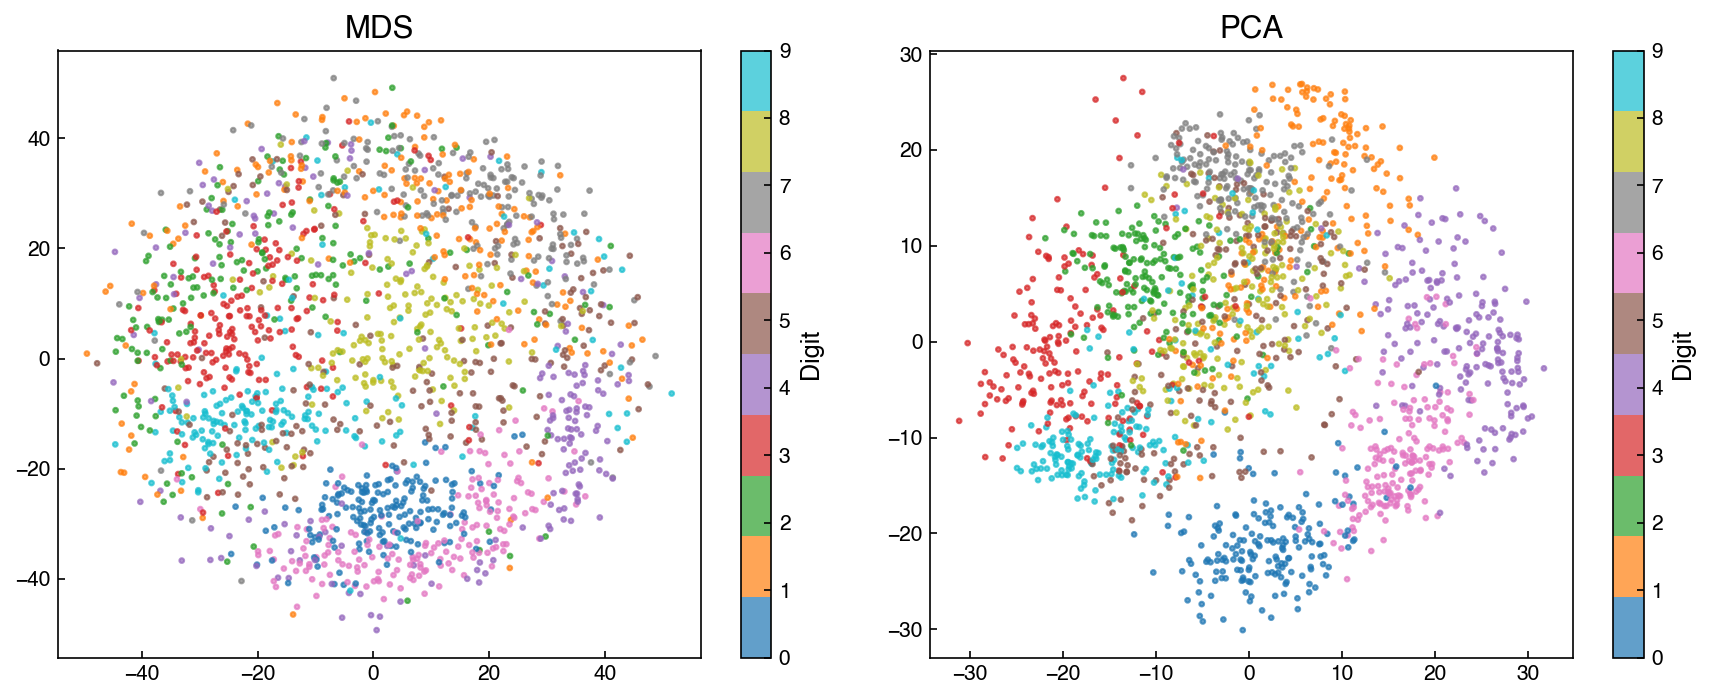

In [23]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, n_init=1, max_iter=100)
X_mds = mds.fit_transform(X_mnist)

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_mnist)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_plot, title in zip(axes, [X_mds, X_pca2], ['MDS', 'PCA']):
    sc = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_mnist, cmap='tab10', s=5, alpha=0.7)
    fig.colorbar(sc, ax=ax, label='Digit')
    ax.set_title(title)
plt.tight_layout()

print(f'Stress MDS: {stress(X_mds, X_mnist):.4f}')
print(f'Stress PCA: {stress(X_pca2, X_mnist):.4f}')

MDS directly optimizes stress and therefore achieves lower stress than PCA, but the visual cluster separation is not dramatically better with a limited number of iterations.

### t-SNE

t-distributed Stochastic Neighbor Embedding (**t-SNE**) uses a probabilistic similarity measure based on the t-distribution: points that are nearby in the original space are given high probability of being neighbors in the embedding, while distant points are pushed apart. For roughly a decade it was the default tool for visualizing high-dimensional data, and you will encounter it constantly in the literature — though for new work it has largely been superseded by UMAP (next section).

The standard recipe is to first reduce the data to 30–50 components with PCA (retaining most of the variance) and then run t-SNE on the reduced representation — computing pairwise similarities in the full 64-dimensional space is slow and adds little:

Text(0.5, 1.0, 't-SNE on PCA-reduced MNIST (30 components)')

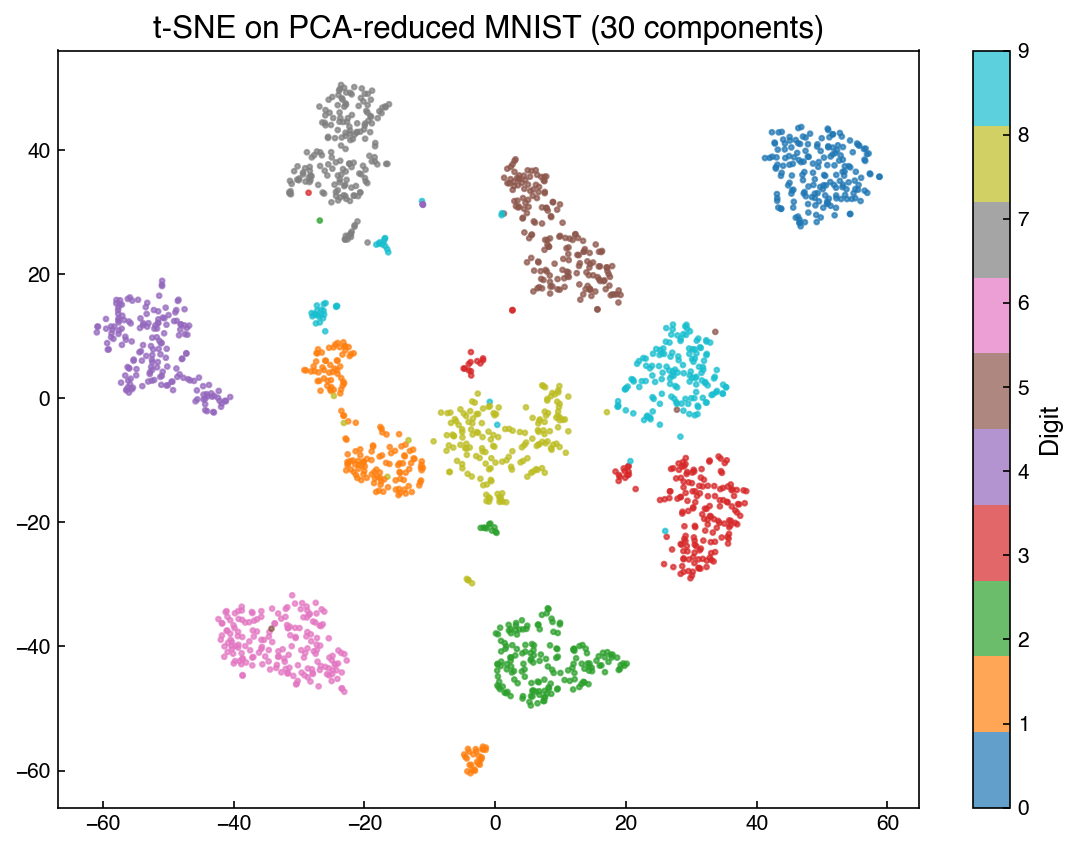

In [24]:
from sklearn.manifold import TSNE

pca_pre = PCA(n_components=30)
X_pca_pre = pca_pre.fit_transform(X_mnist)

tsne = TSNE(n_components=2, perplexity=30.0,
            learning_rate=200.0, max_iter=1000,
            init='random', random_state=42)
X_tsne = tsne.fit_transform(X_pca_pre)

fig, ax = plt.subplots()
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_mnist, cmap='tab10', s=5, alpha=0.7)
fig.colorbar(sc, ax=ax, label='Digit')
ax.set_title('t-SNE on PCA-reduced MNIST (30 components)')

t-SNE produces well-separated clusters on image data, though the axes have no interpretable meaning.

:::{note}
**t-SNE hyperparameters:** t-SNE has many hyperparameters without clear physical meaning, and results depend on all of them. `perplexity` (roughly, the number of effective nearest neighbors; typically 5–50) is the most important to tune; `learning_rate` and `max_iter` also affect results, and the embedding is not deterministic unless `random_state` is set. Use t-SNE for visualization only — global distances between clusters in the embedding are not meaningful.
:::

:::{exercise}
:label: ex-eda-tsne-perp

Using the PCA-reduced MNIST data (`X_pca_pre` above), run t-SNE with `perplexity` values of 5, 30, and 100 (keep all other parameters fixed, and set `random_state=42`). Plot the three 2D embeddings side-by-side colored by digit. How does perplexity affect the size and separation of the clusters? Which value gives the clearest separation?
:::

### UMAP

Uniform Manifold Approximation and Projection (**UMAP**) is a more recent manifold learning method (McInnes et al., 2018) that has largely replaced t-SNE as the default visualization tool for high-dimensional data. It is based on Riemannian geometry and algebraic topology, but the practical intuition is similar to t-SNE: nearby points in the original space are pulled together in the embedding, while distant points are pushed apart.

UMAP has three key advantages over t-SNE:

1. **Speed** — UMAP scales approximately as $O(N^{1.14})$ in practice, making it feasible on datasets with millions of points where t-SNE becomes prohibitive.
2. **Global structure** — Unlike t-SNE, UMAP better preserves the global relationships between clusters, not just local neighborhood structure.
3. **Projectability** — A fitted UMAP model can transform new points, enabling use in downstream pipelines.

/opt/homebrew/Caskroom/miniforge/base/envs/DA4CHE/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Text(0.5, 1.0, 'UMAP — MNIST')

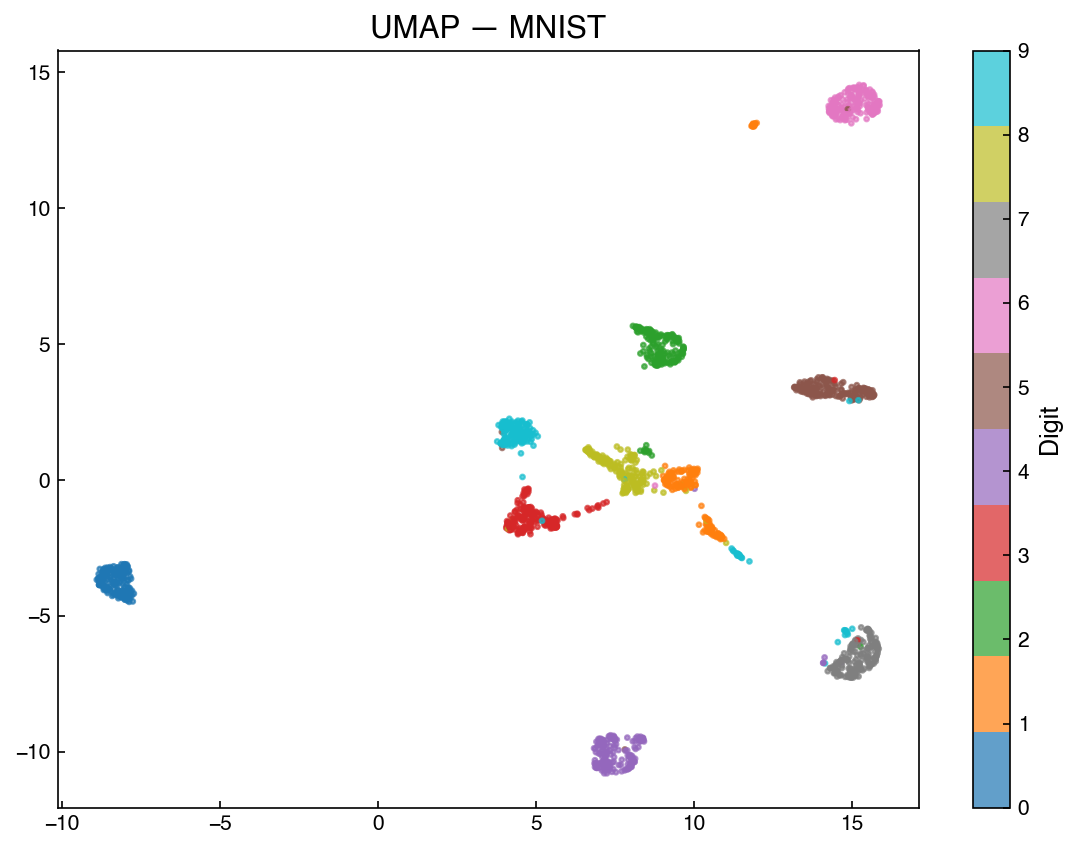

In [25]:
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_mnist)

fig, ax = plt.subplots()
sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=y_mnist, cmap='tab10', s=5, alpha=0.7)
fig.colorbar(sc, ax=ax, label='Digit')
ax.set_title('UMAP — MNIST')

The two key hyperparameters are `n_neighbors` (controls the balance between local and global structure — larger values give more global context) and `min_dist` (controls how tightly points are packed in the embedding — smaller values produce more clustered layouts).

Because UMAP is projectable, a fitted model can transform new points without re-running the full embedding — useful for applying a dimensionality reduction learned on training data to a held-out test set:

/opt/homebrew/Caskroom/miniforge/base/envs/DA4CHE/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


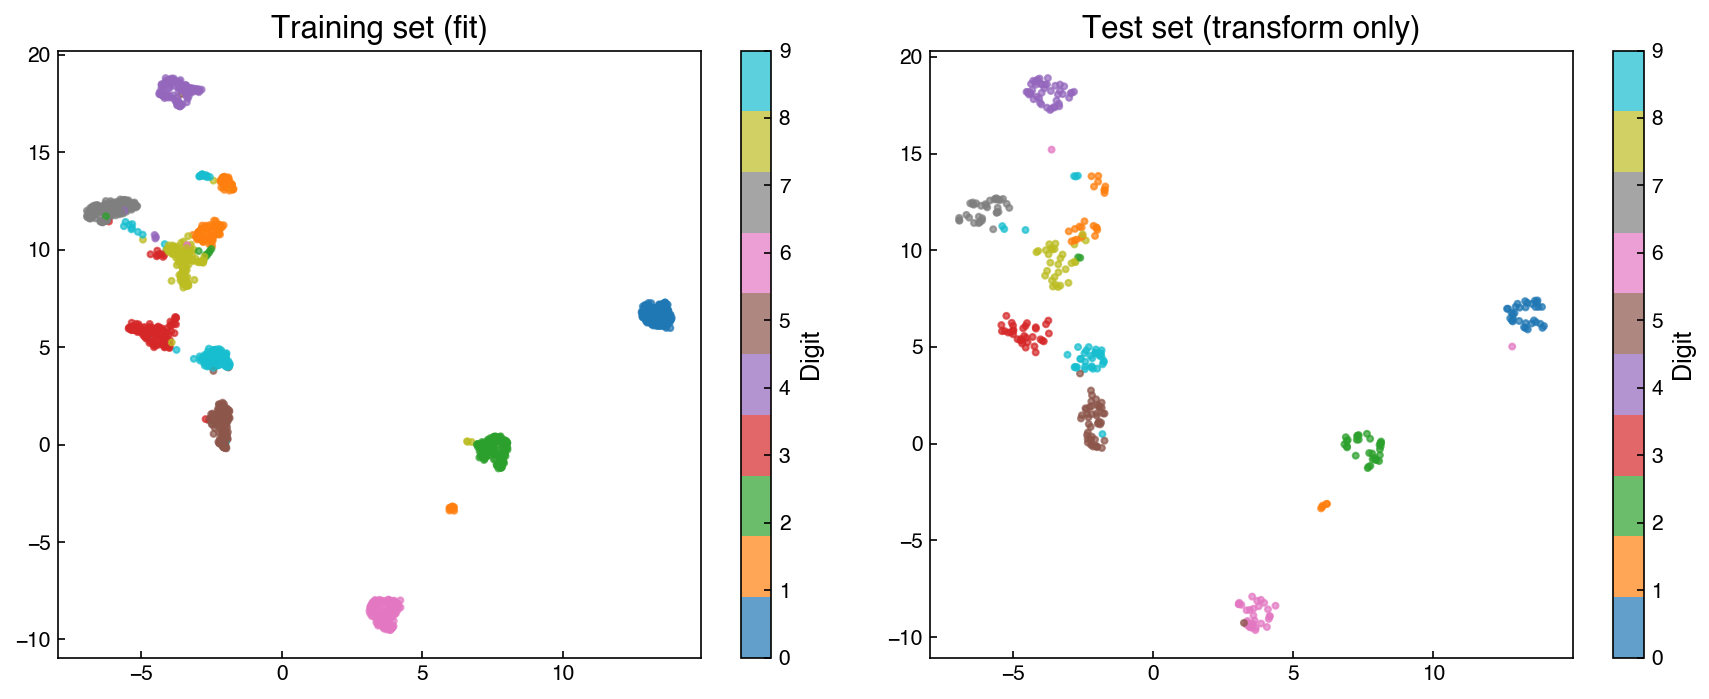

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_mnist, y_mnist, test_size=0.2, random_state=42)

reducer_proj = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_train_umap = reducer_proj.fit_transform(X_train)   # fit on training data
X_test_umap  = reducer_proj.transform(X_test)         # project test points into same space

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_plot, y_plot, title in zip(
        axes,
        [X_train_umap, X_test_umap],
        [y_train, y_test],
        ['Training set (fit)', 'Test set (transform only)']):
    sc = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap='tab10', s=8, alpha=0.7)
    fig.colorbar(sc, ax=ax, label='Digit')
    ax.set_title(title)
plt.tight_layout()

Test points land in the same regions as their corresponding training classes, confirming that the embedding generalizes — the same fit-on-train, transform-both pattern used with LDA above.

:::{exercise}
:label: ex-eda-umap-params

Fit UMAP on the MNIST dataset with three combinations of hyperparameters: (a) `n_neighbors=5, min_dist=0.01`, (b) `n_neighbors=15, min_dist=0.1` (the default above), and (c) `n_neighbors=50, min_dist=0.5`. Plot the three embeddings side-by-side colored by digit. Describe how increasing `n_neighbors` changes the structure of the embedding.
:::

### PHATE

PHATE (Potential of Heat-diffusion for Affinity-based Trajectory Embedding; Moon et al., 2019) is a manifold learning method designed to preserve **trajectory and branching structure** in the embedding. While t-SNE and UMAP excel at revealing discrete clusters, PHATE is particularly effective when the data lies along continuous paths where intermediate states are physically meaningful.

The key idea is to compute a **diffusion operator** that models how information spreads through the data manifold, then embed points based on their *potential distances* under this diffusion. This captures multi-scale structure: fine local neighborhoods and broad global trajectories are both represented faithfully.

PHATE was developed for single-cell genomics, where cells trace continuous developmental trajectories rather than falling into discrete groups. Analogous trajectory structure plausibly arises in chemical engineering data — plant states evolving through startup, shutdown, or grade transitions; reaction pathways passing through a sequence of intermediate compositions; processing conditions tracing a route through composition space — though published applications in this space are still rare. Treat PHATE as a tool worth trying when your data has a path-like character rather than discrete clusters, not as an established ChE workhorse.

Text(0.5, 1.0, 'PHATE — MNIST')

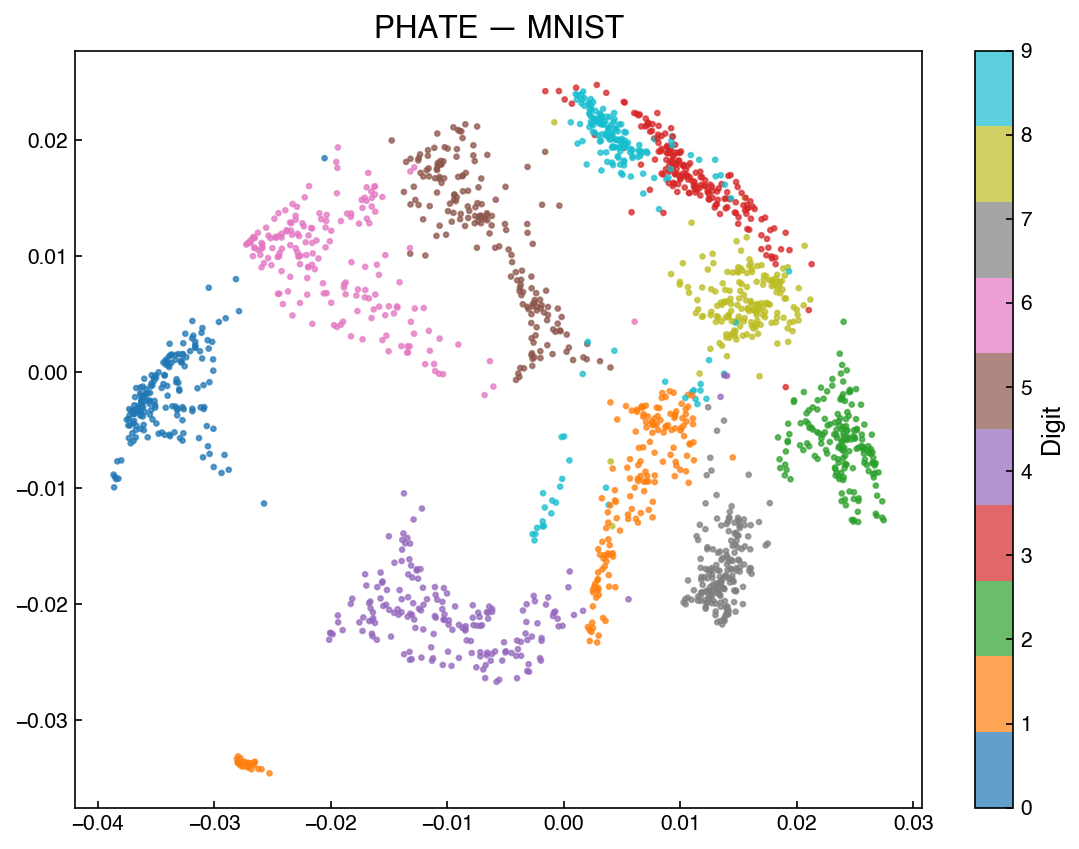

In [27]:
import phate

phate_op = phate.PHATE(n_components=2, knn=5, decay=40, t='auto',
                       random_state=42, verbose=0)
X_phate = phate_op.fit_transform(X_mnist)

fig, ax = plt.subplots()
sc = ax.scatter(X_phate[:, 0], X_phate[:, 1], c=y_mnist, cmap='tab10', s=5, alpha=0.7)
fig.colorbar(sc, ax=ax, label='Digit')
ax.set_title('PHATE — MNIST')

On MNIST (a dataset with discrete clusters rather than trajectories), PHATE tends to arrange digits with similar stroke structure closer together — for example, 8, 3, and 9 share curved closed strokes and typically appear in the same region of the embedding, while 1 and 7 appear nearby due to their shared vertical stroke. This reflects PHATE's emphasis on global connectivity and smooth transitions rather than isolated blobs. On process data with genuine trajectories, this behavior is exactly what is desired.

The key hyperparameters are `knn` (number of nearest neighbors for the affinity graph — smaller values capture finer local structure) and `decay` (sharpness of the affinity kernel — larger values produce a tighter, more local kernel).

### Comparison: Manifold Learning vs. PCA

| Property | PCA | LDA | Kernel PCA | MDS | t-SNE | UMAP | PHATE |
|---|---|---|---|---|---|---|---|
| Supervised? | No | Yes | No | No | No | No | No |
| Linear? | Yes | Yes | No | No | No | No | No |
| Projectable? | Yes | Yes | Yes | No | No | Yes | No |
| Invertible? | Yes | No | Yes (approx.) | No | No | Approx. | No |
| Speed | Fast | Fast | Moderate | Slow ($O(N^2)$) | Slow ($O(N^2)$) | Fast ($O(N^{1.1})$) | Moderate |
| Global structure | Yes | Class-driven | Partial | Yes | Poor | Good | Excellent |
| Best for | Linear, compression | Labeled data, $\le C-1$ dims | Nonlinear, small | Distance | Visualization | Visualization + pipelines | Trajectories, branching |

Manifold techniques provide powerful insight into data structure but are generally not projectable and scale poorly compared to PCA. For visualization, UMAP is the current best practice for cluster-structured data; PHATE is preferred when the data has trajectory or branching structure.

## Autoencoding

:::{figure} images/autoencoder.png
:name: fig-autoencoder
:width: 70%

Schematic of an autoencoder. The encoder network maps the input to a low-dimensional bottleneck representation (latent space); the decoder network reconstructs the original input from the bottleneck. Training minimizes the reconstruction error.
:::

An **autoencoder** is a neural network trained to reproduce its own input. The architecture has a narrow hidden layer (the *bottleneck* or *latent space*) with fewer units than the input, forcing the network to learn a compressed representation.

The network has two parts:
- **Encoder** — maps the high-dimensional input $\mathbf{x}$ to a low-dimensional latent vector $\mathbf{z}$
- **Decoder** — maps $\mathbf{z}$ back to a reconstruction $\hat{\mathbf{x}}$

Training minimizes the reconstruction error $\|\mathbf{x} - \hat{\mathbf{x}}\|^2$ over the training set. Because the bottleneck forces information compression, the latent space learns the most important structure without any labels.

**Advantages over PCA:**
- Projectable and invertible by construction
- Captures nonlinear structure
- Scales efficiently on large datasets via stochastic gradient descent

**Disadvantages:**
- Requires large training datasets
- Architecture and hyperparameters must be tuned
- No interpretable relationship between latent dimensions and original features

Autoencoders are an active research area. Specialized variants — variational autoencoders (VAEs) and denoising autoencoders — are used in generative modeling, anomaly detection, and representation learning. We revisit this topic in the Generative Models chapter.

:::{note}
PyTorch and neural networks are outside the core scope of this course and are not required material. The example below is provided purely for reference, to make the autoencoder concept concrete for students who want to explore further.
:::

The following example builds a simple autoencoder on the MNIST digits dataset using PyTorch. The encoder compresses 64 pixel values to a 2-dimensional latent space; the decoder reconstructs the image from that 2-D code.

In [28]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Data ──────────────────────────────────────────────────────────────────────
X_tensor = torch.tensor(X_mnist / 16.0, dtype=torch.float32)   # scale to [0, 1]
dataset   = TensorDataset(X_tensor)
loader    = DataLoader(dataset, batch_size=128, shuffle=True)

# ── Model ─────────────────────────────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, input_dim=64, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32),         nn.ReLU(),
            nn.Linear(32, input_dim),  nn.Sigmoid()
        )

    def forward(self, x):
        z    = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

model     = Autoencoder(input_dim=64, latent_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(30):
    total_loss = 0.0
    for (batch,) in loader:
        x_hat, _ = model(batch)
        loss = criterion(x_hat, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:3d}  loss = {total_loss / len(dataset):.5f}")

Epoch  10  loss = 0.07352
Epoch  20  loss = 0.06567
Epoch  30  loss = 0.06165


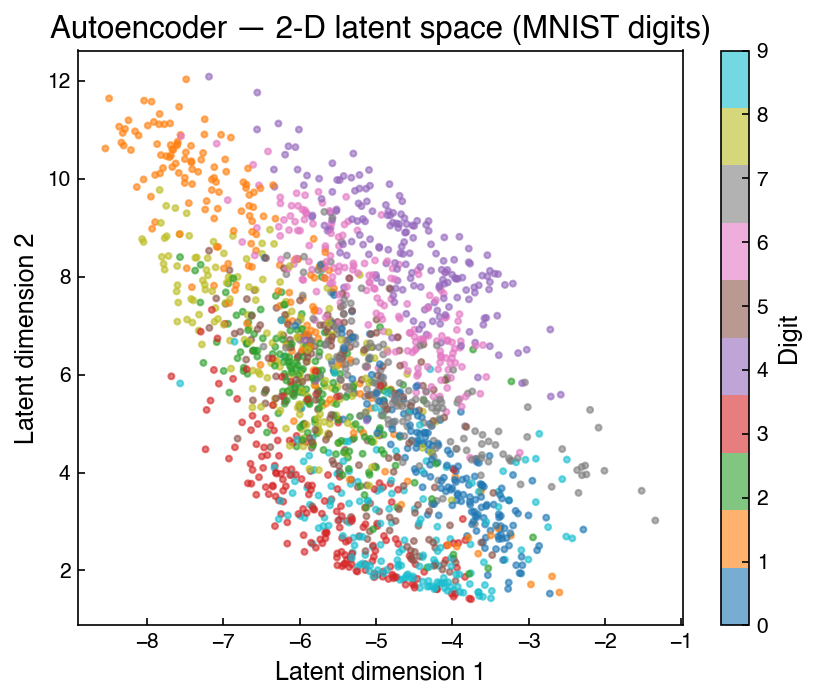

In [29]:
# ── Visualize the 2-D latent space ────────────────────────────────────────────
model.eval()
with torch.no_grad():
    _, Z = model(X_tensor)
Z = Z.numpy()

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(Z[:, 0], Z[:, 1], c=y_mnist, cmap='tab10', s=8, alpha=0.6)
fig.colorbar(sc, ax=ax, label='Digit')
ax.set_xlabel('Latent dimension 1')
ax.set_ylabel('Latent dimension 2')
ax.set_title('Autoencoder — 2-D latent space (MNIST digits)')
plt.tight_layout()

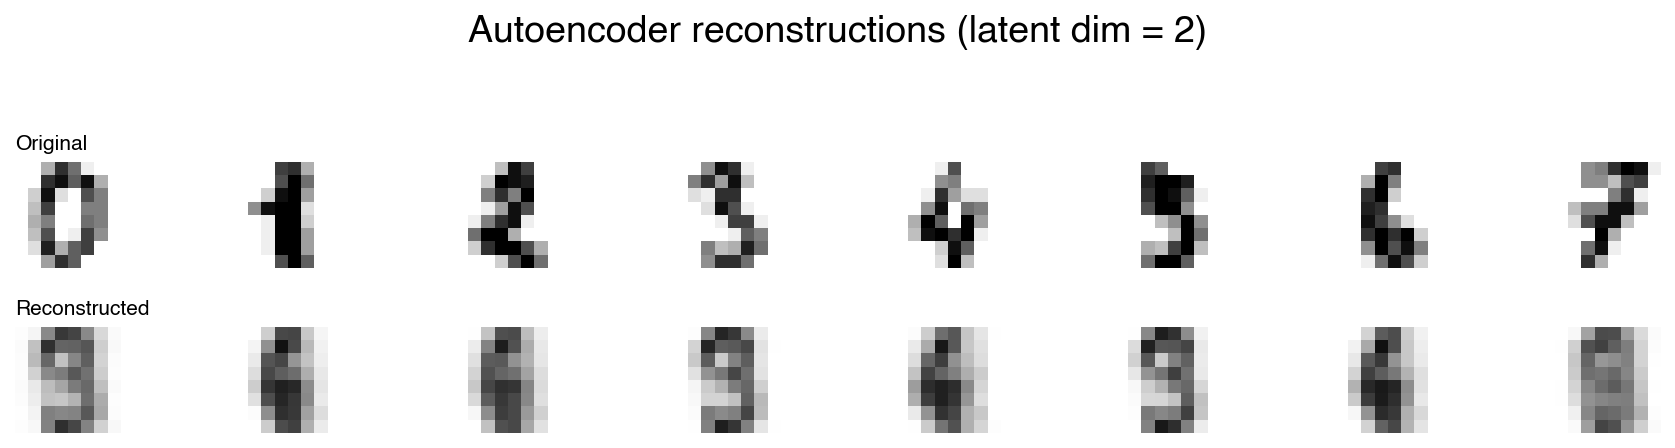

In [30]:
# ── Inspect a reconstruction ──────────────────────────────────────────────────
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(12, 3))
model.eval()
with torch.no_grad():
    x_hat_all, _ = model(X_tensor)

for i in range(n_show):
    axes[0, i].imshow(X_tensor[i].numpy().reshape(8, 8),
                      cmap='binary', vmin=0, vmax=1)
    axes[1, i].imshow(x_hat_all[i].numpy().reshape(8, 8),
                      cmap='binary', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left', fontsize=10)
axes[1, 0].set_title('Reconstructed', loc='left', fontsize=10)
plt.suptitle('Autoencoder reconstructions (latent dim = 2)', y=1.02)
plt.tight_layout()

:::{note}
With only 2 latent dimensions the reconstructions are blurry — the bottleneck is very tight. Increasing `latent_dim` to 8 or 16 produces sharper results at the cost of a less compact representation. The trade-off between reconstruction quality and compression is the central design decision when sizing the bottleneck.

Beyond the bottleneck size, neural network performance is highly sensitive to a range of hyperparameters: learning rate, choice of optimizer, activation functions (ReLU, tanh, GELU, …), network depth and width, batch size, number of training epochs, and regularization strategy. Each of these can meaningfully affect whether the model converges, how quickly, and to what quality of solution. Finding a good combination typically requires systematic search (grid search, random search, or Bayesian optimization) and substantial domain experience. This complexity is a large part of why neural networks — despite their power — are not covered as core material in this course.
:::

:::{exercise}
:label: ex-eda-autoencoder-design

Sketch an autoencoder architecture that compresses a 20-dimensional input into a 3-dimensional latent space, specifying the width of each encoder and decoder layer.
:::


## Summary

- Dimensionality reduction compresses high-dimensional data into a lower-dimensional representation for visualization, denoising, or model efficiency.
- **Retained variance** and **stress** are complementary quality metrics: variance measures global compression fidelity; stress measures pairwise distance preservation.
- **PCA** finds orthonormal directions of maximum variance via eigendecomposition of the covariance matrix. It is linear, projectable, invertible, and fast — the default first choice.
- A **scree plot** of cumulative explained variance guides the choice of the number of components $k$.
- **Kernel PCA** extends PCA to nonlinear data using the kernel trick. The RBF kernel hyperparameter $\gamma$ controls the locality of the similarity measure.
- **LDA** is the supervised counterpart of PCA: it maximizes between-class relative to within-class variance, yields at most $C - 1$ components for $C$ classes, and is projectable — making it a highly effective feature extractor when labels are available.
- **Manifold learning** methods (MDS, t-SNE) optimize distance preservation directly and reveal nonlinear structure, but are not projectable, not invertible, and scale as $O(N^2)$.
- **t-SNE** produces high-quality local cluster visualization but is slow, not projectable, and sensitive to hyperparameters. PCA pre-reduction (to ~30 components) is part of the standard recipe. For new work it has largely been superseded by UMAP.
- **Incremental PCA** (`IncrementalPCA`) fits PCA in mini-batches and is the go-to choice for datasets too large to fit in memory; results are nearly identical to full SVD-based PCA.
- **UMAP** is faster than t-SNE, better preserves global structure, and is projectable — it is the current best practice for visualization and nonlinear feature extraction.
- **PHATE** uses heat diffusion to capture trajectory and branching structure; it is particularly suited for process data with continuous state transitions or reaction pathway data.
- **Autoencoders** use neural networks to learn nonlinear, projectable, and invertible representations, at the cost of requiring large datasets and hyperparameter tuning.

## Additional Reading

- [scikit-learn: PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [scikit-learn: KernelPCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html)
- [scikit-learn: MDS](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html)
- [scikit-learn: TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
- [Distill.pub: How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/)
- [UMAP documentation](https://umap-learn.readthedocs.io/)
- [McInnes et al. (2018): UMAP paper](https://arxiv.org/abs/1802.03426)
- [PHATE documentation](https://phate.readthedocs.io/)
- [Moon et al. (2019): PHATE paper](https://www.nature.com/articles/s41587-019-0336-3)
- [scikit-learn: IncrementalPCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.IncrementalPCA.html)
- [Hastie, Tibshirani & Friedman: The Elements of Statistical Learning, Ch. 14](https://hastie.su.domains/ElemStatLearn/)